In [1]:
from detectron2.data import detection_utils as utils
from detectron2.structures import BoxMode
import detectron2.data.transforms as T
import logging
import cv2
from cv2 import hconcat
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy, random

#-----------------------------------------------
# Function that retrieves a standard dataset compatible with detectron2
#
def get_dict(type):
  """ Returns a list[dict] containing information about the dataset """
  import pickle
  root = 'D:/Project-Dataset/LS-SAR-sample/datasets/' + type + '/'
  with open(root + "standardDict.pkl", "rb") as input_file:
      return pickle.load(input_file)
     
#-----------------------------------------------
# Copy Paste
# Create copy+paste subroutine to be used in data augmentation
#
class copyPaste():
  def __init__(self, annotation):
    self.ann = copy.deepcopy(annotation)

  def load_image(self, image = None):
    self.image = image
    if self.image is None:
      self.image = utils.read_image(self.ann["file_name"], format="BGR")
    self.mask()

  def mask(self):
    FILTER = 3
    BLUR = 5
    temp = cv2.imread(self.ann["file_name"], 0)
    temp = cv2.equalizeHist(temp)
    temp = cv2.GaussianBlur(temp,(BLUR,BLUR),0)
    ret,th = cv2.threshold(temp,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    mask = np.where(th == 255, 1, 0).astype('uint8')
    kernel = np.ones((FILTER,FILTER),np.uint8)
    self.mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

  def valid_copy(self, xmin, xmax, ymin, ymax):
    valid = xmin > 0 and xmax < 800 and ymin > 0 and ymax < 800
    bboxs = [i['bbox'] for i in self.ann['annotations']]
    iou = self.calc_iou(bboxs, [xmin, ymin, xmax, ymax])
    valid = valid and np.all(np.isclose(iou, 0))
    valid = valid and (0 == np.sum(self.mask[ymin:ymax, xmin:xmax]))
    return valid 

  def calc_iou(self, bboxes, bbox):
    #https://medium.com/@venuktan/vectorized-intersection-over-union-iou-in-numpy-and-tensor-flow-4fa16231b63d
    x11, y11, x12, y12 = np.split(np.array(bboxes), 4, axis=1)
    x21, y21, x22, y22 = np.split(np.array(bbox), 4, axis=0)
    xA = np.maximum(x11, np.transpose(x21))
    yA = np.maximum(y11, np.transpose(y21))
    xB = np.minimum(x12, np.transpose(x22))
    yB = np.minimum(y12, np.transpose(y22))
    interArea = np.maximum((xB - xA + 1), 0) * np.maximum((yB - yA + 1), 0)
    boxAArea = (x12 - x11 + 1) * (y12 - y11 + 1)
    boxBArea = (x22 - x21 + 1) * (y22 - y21 + 1)
    iou = interArea / (boxAArea + np.transpose(boxBArea) - interArea)
    return iou

  def parse(self):
    bbox = self.ann['annotations'][self.index]['bbox']
    self.xmin = bbox[0]
    self.xmax = bbox[2]
    self.ymin = bbox[1]
    self.ymax = bbox[3]

  def copyImg(self):
    self.parse()
    self.copy = self.image[self.ymin: self.ymax, self.xmin:self.xmax, :]
    
  def translate(self):
    xmin = self.xmin + self.xdel
    xmax = self.xmax + self.xdel
    ymin = self.ymin + self.ydel
    ymax = self.ymax + self.ydel
    return (xmin, xmax, ymin, ymax)

  def update_ann(self, xmin, ymin, xmax, ymax):
    new = {'bbox': [xmin, ymin, xmax, ymax],
           'bbox_mode': BoxMode.XYXY_ABS,
           'category_id': 0}
    self.ann['annotations'].append(new)

  def copyPaste(self, index, xdel, ydel):
    self.index = index
    self.copyImg()
    self.xdel = xdel
    self.ydel = ydel
    xmin, xmax, ymin, ymax = self.translate()
    if self.valid_copy(xmin, xmax, ymin, ymax):
      temp = self.image.copy()
      temp[ymin:ymax, xmin:xmax, :] = self.copy
      self.image = temp
      self.update_ann(xmin, ymin, xmax, ymax)

  def getImage(self):
    return self.image
  
  def getAnn(self):
    return self.ann

from detectron2.utils.visualizer import Visualizer
#-------------------------------
# Data Augmentation
def printImage(im, dataset_dict):
  v = Visualizer(im[:, :, ::-1], scale=1)
  out = v.draw_dataset_dict(dataset_dict)
  image = out.get_image()[:, :, ::-1]
  return image


# https://gilberttanner.com/blog/detectron-2-object-detection-with-pytorch
def custom_mapper(dataset_dict, copy_paste = True):
    dataset_dict = copy.deepcopy(dataset_dict)
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    # Only for viewing
    preImage = printImage(image, dataset_dict) # only for viewing

    # Copy paste Ship
    if copy_paste:
      PI = 10
      SIGMA = 600
      preAnns = len(dataset_dict['annotations'])
      ex = copyPaste(dataset_dict)
      ex.load_image(image)
      for i in range(preAnns):
        pastes = random.randint(1,PI)
        for j in range(pastes):
          sample = np.random.multivariate_normal([0,0], SIGMA*np.diag((2,2))).astype(int)
          xdel = sample[0]
          ydel = sample[1]
          ex.copyPaste(i, xdel, ydel)

      dataset_dict = ex.getAnn()
      postAnns = len(dataset_dict['annotations'])
      image = ex.getImage()
      #logger = logging.getLogger("detectron2")
      #logger.info(f"Annotations before {preAnns}, Annotations after {postAnns}")

    transform_list = [
        # Only using simple data augmentations
        #T.Resize((800,800)),
        T.RandomBrightness(0.8, 1.8),
        T.RandomContrast(0.6, 1.3),
        T.RandomSaturation(0.8, 1.4),
        T.RandomRotation(angle=[90, 90]),
        T.RandomLighting(0.7),
        T.RandomFlip(prob=0.4, horizontal=False, vertical=True),
    ]

    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2])
        for obj in dataset_dict.pop("annotations")
        if obj.get("iscrowd", 0) == 0
    ]

    instances = utils.annotations_to_instances(annos, image.shape[:2])
    dataset_dict["instances"] = utils.filter_empty_instances(instances)

    '''
    # only for viewing
    dataset_dict['annotations'] = annos
    postImage = printImage(image, dataset_dict)
    dataset_dict.pop('annotations')
    cv2_imshow(cv2.hconcat([preImage, postImage]))
    '''
    dataset_dict['annotations'] = annos
    postImage = printImage(image, dataset_dict)
    dataset_dict.pop('annotations')
    #--------------------------------------------
    # hconcat Before & After Augmented Images  
    # plt.imshow(cv2.hconcat([preImage, postImage]))
    plt.title('Copy & Paste-Ship')
    plt.imshow(postImage)
    plt.axis('on')
    plt.show()
    return dataset_dict

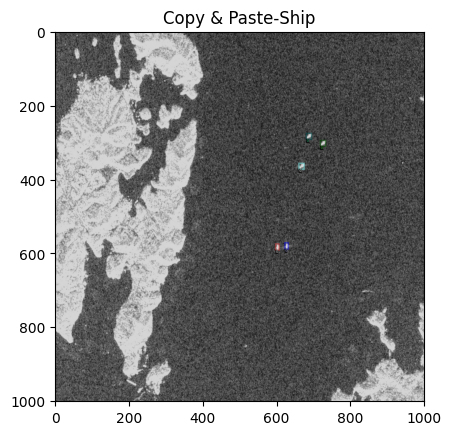

In [2]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.structures import BoxMode

#==============================================================
# Registration : Dataset Names 
# Register train, test, test_offshore, test_inshore datasets

# Register
for d in ["train", "test", "test_offshore", "test_inshore", "train/train_w_val", "train/validation", "train/toy"]:
    DatasetCatalog.register(d, lambda d=d: get_dict(d))
    MetadataCatalog.get(d).set(thing_classes=["ship"])

#==============================================================
# Instances of metadata

test_offshore = MetadataCatalog.get('test_offshore')

#%%
#-------------------------------
#   Visualize Augmentation
from detectron2.data import detection_utils as utils
test_offshore = get_dict('test_offshore')
#train_sample = [i for i in train if i['file_name']=='/content/drive/MyDrive/SSDD/datasets/train/04_11_8.jpg'][0]
sample = test_offshore[0]
test = custom_mapper(sample)